# 전국 공간 데이터 EDA (지형, 등산로, 임도, 소방시설 및 토지피복)
- **분석 목적**: 전국 및 강원도 지역의 산불 발생 데이터를 지형 특성 및 인근 예방/소방 시설물, 토지피복 등 공간 변수들과 결합하여 물리적/공간적 취약 요소를 규명하고 예측 모델링용 파생 피처를 구축함.
- **분석 프레임워크**: 3차원 구면 KDTree 기반 고속 최근접 매칭 → 지형·시설물·수종 파생 피처 60종 구축 → 강원도 vs 타 지역 비교 통계 검정 → 5대 가설 OLS/T-test 검증


In [1]:
# 라이브러리 및 한글 폰트 설정
import sys, os, re
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path
from scipy.spatial import KDTree
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

font_path = 'C:/Windows/Fonts/malgun.ttf'
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

sns.set_theme(
    style='whitegrid',
    font=font_name,
    rc={
        'font.family': font_name,
        'font.sans-serif': [font_name],
        'axes.unicode_minus': False
    }
)
plt.rcParams['font.family'] = font_name
plt.rcParams['font.sans-serif'] = [font_name]
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)
print('matplotlib 한글 폰트 설정 완료:', plt.rcParams['font.family'])


matplotlib 한글 폰트 설정 완료: ['Malgun Gothic']


In [2]:
# 데이터 경로 설정
BASE_DIR = Path('D:/farm-system-public-02')
DATA_DIR = BASE_DIR / 'data'
SPATIAL_DIR = DATA_DIR / '산불_공간DB'

FIRE_PATH = DATA_DIR / '산불_전국/산불발생위치도_전국.csv'
TOPO_PATH = SPATIAL_DIR / '산불발생위치도_지형특성계산.csv'
FACILITY_PATH = SPATIAL_DIR / '전국_산불소화시설.csv'
STATION_PATH = SPATIAL_DIR / '전국_소방서_좌표.csv'
WATER_PATH = SPATIAL_DIR / '전국_소방용수시설.csv'
ROAD_PATH = SPATIAL_DIR / '전국_임도망도.csv'
TRAIL_PATH = SPATIAL_DIR / '전국_등산로.csv'
LANDCOVER_DIR = SPATIAL_DIR / '산불발생_토지피복도'


## 1. 공간 피처 연산 및 병합 (KDTree를 이용한 최단 거리 매칭)
- **3차원 구면 좌표계 변환**: 경위도 각도 왜곡 문제를 극복하기 위해 `WGS84` 구면 좌표를 3차원 Cartesian 좌표 `(X, Y, Z)`로 투영한 뒤 KDTree를 빌드 및 매칭하여 정확도를 확보합니다.
- **LineString vertices 추출**: 임도망과 등산로 노선의 LineString WKT 텍스트로부터 노드 정점들을 추출한 뒤, 각 산불 발생 지점에서의 고속 최단 수렴 거리를 계산합니다.
- **토지피복 비율**: 300m 반경 버퍼 내의 토지피복 면적 비중을 산출해 대분류 및 주요 산림 수종 비율 파생 피처를 구축합니다.


In [3]:
# 공간 데이터 연산 파이프라인 및 캐싱
CACHE_PATH = BASE_DIR / 'jsw/EDA/fire_spatial_features.csv'

def latlon_to_3d(lat, lon):
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)
    return np.column_stack((x, y, z))

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    a = np.sin(dlat/2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

wkt_re = re.compile(r'[-+]?\d*\.\d+|\d+')
def parse_wkt_points(wkt_str):
    if not isinstance(wkt_str, str):
        return []
    numbers = [float(x) for x in wkt_re.findall(wkt_str)]
    points = []
    for i in range(0, len(numbers) - 1, 2):
        points.append((numbers[i+1], numbers[i]))
    return points

if not CACHE_PATH.exists():
    print('캐시 파일이 존재하지 않아 공간 피처 연산을 시작합니다...')
    fire_df = pd.read_csv(FIRE_PATH, encoding='utf-8-sig')
    topo_df = pd.read_csv(TOPO_PATH, encoding='utf-8-sig')
    merged_df = pd.merge(fire_df, topo_df, on='fire_id', how='inner')
    fire_coords = latlon_to_3d(merged_df['위도'].values, merged_df['경도'].values)
    
    # 1. 소방서 매칭
    station_df = pd.read_csv(STATION_PATH, encoding='utf-8-sig')
    station_coords = latlon_to_3d(station_df['위도'].values, station_df['경도'].values)
    station_tree = KDTree(station_coords)
    dists, idxs = station_tree.query(fire_coords)
    merged_df['nearest_station_dist_km'] = haversine_distance(
        merged_df['위도'].values, merged_df['경도'].values,
        station_df['위도'].values[idxs], station_df['경도'].values[idxs])
    merged_df['nearest_station_name'] = station_df['소방서 및 안전센터명'].values[idxs]
    
    # 2. 산불소화시설 매칭
    facility_df = pd.read_csv(FACILITY_PATH, encoding='utf-8-sig')
    facility_coords = latlon_to_3d(facility_df['위도'].values, facility_df['경도'].values)
    facility_tree = KDTree(facility_coords)
    dists_fac, idxs_fac = facility_tree.query(fire_coords)
    merged_df['nearest_facility_dist_km'] = haversine_distance(
        merged_df['위도'].values, merged_df['경도'].values,
        facility_df['위도'].values[idxs_fac], facility_df['경도'].values[idxs_fac])
    merged_df['nearest_facility_remote'] = facility_df['원격제어'].values[idxs_fac]
    
    # 3. 소방용수시설 매칭
    water_df = pd.read_csv(WATER_PATH, encoding='utf-8-sig')
    water_coords = latlon_to_3d(water_df['위도'].values, water_df['경도'].values)
    water_tree = KDTree(water_coords)
    dists_wat, idxs_wat = water_tree.query(fire_coords)
    merged_df['nearest_water_dist_km'] = haversine_distance(
        merged_df['위도'].values, merged_df['경도'].values,
        water_df['위도'].values[idxs_wat], water_df['경도'].values[idxs_wat])
    
    # 4. 임도망 매칭
    road_df = pd.read_csv(ROAD_PATH, encoding='utf-8-sig')
    road_vertices, road_row_idxs = [], []
    for idx, row in road_df.iterrows():
        pts = parse_wkt_points(row['공간좌표'])
        for pt in pts:
            road_vertices.append(pt)
            road_row_idxs.append(idx)
    road_vertices = np.array(road_vertices)
    road_row_idxs = np.array(road_row_idxs)
    road_3d = latlon_to_3d(road_vertices[:, 0], road_vertices[:, 1])
    road_tree = KDTree(road_3d)
    dists_road, idxs_road = road_tree.query(fire_coords)
    nearest_road_row_idxs = road_row_idxs[idxs_road]
    merged_df['nearest_road_dist_km'] = haversine_distance(
        merged_df['위도'].values, merged_df['경도'].values,
        road_vertices[idxs_road, 0], road_vertices[idxs_road, 1])
    merged_df['nearest_road_width_m'] = road_df['폭(m)'].values[nearest_road_row_idxs]
    merged_df['nearest_road_length_km'] = road_df['도형길이'].values[nearest_road_row_idxs] / 1000.0
    
    # 5. 등산로 매칭
    trail_df = pd.read_csv(TRAIL_PATH, encoding='utf-8-sig')
    trail_vertices, trail_row_idxs = [], []
    for idx, row in trail_df.iterrows():
        pts = parse_wkt_points(row['공간좌표'])
        for pt in pts:
            trail_vertices.append(pt)
            trail_row_idxs.append(idx)
    trail_vertices = np.array(trail_vertices)
    trail_row_idxs = np.array(trail_row_idxs)
    trail_3d = latlon_to_3d(trail_vertices[:, 0], trail_vertices[:, 1])
    trail_tree = KDTree(trail_3d)
    dists_trail, idxs_trail = trail_tree.query(fire_coords)
    nearest_trail_row_idxs = trail_row_idxs[idxs_trail]
    merged_df['nearest_trail_dist_km'] = haversine_distance(
        merged_df['위도'].values, merged_df['경도'].values,
        trail_vertices[idxs_trail, 0], trail_vertices[idxs_trail, 1])
    merged_df['nearest_trail_difficulty'] = trail_df['등산로난이도명'].values[nearest_trail_row_idxs]
    merged_df['nearest_trail_material'] = trail_df['등산로재질내용'].values[nearest_trail_row_idxs]
    
    # 6. 토지피복도 매칭
    lc_provinces = [f.name for f in LANDCOVER_DIR.glob('*.gpkg')]
    lc_list = []
    for province_file in lc_provinces:
        df_lc = gpd.read_file(LANDCOVER_DIR / province_file, ignore_geometry=True)
        pivot_dae = df_lc.pivot_table(index='산불ID', columns='대분류명', values='면적_제곱미터', aggfunc='sum', fill_value=0).reset_index()
        forest_df = df_lc[df_lc['중분류명'].isin(['침엽수림', '활엽수림', '혼효림'])]
        if not forest_df.empty:
            pivot_jung = forest_df.pivot_table(index='산불ID', columns='중분류명', values='면적_제곱미터', aggfunc='sum', fill_value=0).reset_index()
            pivot_province = pd.merge(pivot_dae, pivot_jung, on='산불ID', how='outer').fillna(0)
        else:
            pivot_province = pivot_dae
        lc_list.append(pivot_province)
    
    lc_all = pd.concat(lc_list, ignore_index=True).fillna(0).groupby('산불ID').sum().reset_index()
    merged_df = pd.merge(merged_df, lc_all, left_on='fire_id', right_on='산불ID', how='left').fillna(0)
    
    dae_cols = ['초지', '습지', '나지', '산림지역', '수역', '농업지역', '시가화건조지역']
    dae_cols_present = [c for c in dae_cols if c in merged_df.columns]
    merged_df['total_lc_area'] = merged_df[dae_cols_present].sum(axis=1)
    merged_df['total_lc_area_norm'] = merged_df['total_lc_area'].replace(0, 282743)
    
    landcover_cols = [c for c in lc_all.columns if c != '산불ID']
    for col in landcover_cols:
        merged_df[f'{col}_ratio'] = merged_df[col] / merged_df['total_lc_area_norm']
        
    if '산불ID' in merged_df.columns:
        merged_df = merged_df.drop(columns=['산불ID'])
        
    merged_df['is_gangwon'] = merged_df['발생지역시도명'].isin(['강원특별자치도', '강원도'])
    merged_df.to_csv(CACHE_PATH, index=False, encoding='utf-8-sig')
    print('공간 피처 연산 및 캐싱 파일 저장 완료!')
else:
    print('캐시 파일이 존재하므로 로드합니다.')
    merged_df = pd.read_csv(CACHE_PATH, encoding='utf-8-sig')
    print(f'로드 완료. 데이터 형태: {merged_df.shape}')


캐시 파일이 존재하므로 로드합니다.
로드 완료. 데이터 형태: (25036, 60)


### 1-1. 데이터 프로파일링 (결측치 현황 및 기초 통계)


In [4]:
# 전체 데이터 기초 통계 및 결측치 현황
print(f'총 산불 건수: {len(merged_df)}')
print(f'강원도 건수: {merged_df["is_gangwon"].sum()} ({merged_df["is_gangwon"].mean()*100:.1f}%)')
print(f'타 지역 건수: {(~merged_df["is_gangwon"]).sum()}')
print()

# 공간 피처 결측치 현황
spatial_cols = ['고도(m)', '경사도(도)', 'TPI(지형위치지수)', 'TWI(지형다습지수)',
    'nearest_station_dist_km', 'nearest_water_dist_km', 'nearest_facility_dist_km',
    'nearest_trail_dist_km', 'nearest_road_dist_km', 'nearest_road_width_m']
present = [c for c in spatial_cols if c in merged_df.columns]
missing_df = merged_df[present].isnull().sum().to_frame('결측치 수')
missing_df['결측률(%)'] = (missing_df['결측치 수'] / len(merged_df) * 100).round(2)
print('--- 공간 피처 결측치 현황 ---')
print(missing_df)
print()
print('--- 주요 공간 피처 기술통계 ---')
print(merged_df[present].describe().round(4).T)


총 산불 건수: 25036
강원도 건수: 4139 (16.5%)
타 지역 건수: 20897

--- 공간 피처 결측치 현황 ---
                          결측치 수  결측률(%)
고도(m)                         0     0.0
경사도(도)                        0     0.0
TPI(지형위치지수)                   0     0.0
TWI(지형다습지수)                   0     0.0
nearest_station_dist_km       0     0.0
nearest_water_dist_km         0     0.0
nearest_facility_dist_km      0     0.0
nearest_trail_dist_km         0     0.0
nearest_road_dist_km          0     0.0
nearest_road_width_m          0     0.0

--- 주요 공간 피처 기술통계 ---
                            count          mean           std      min  \
고도(m)                     25036.0  1.791273e+02  1.743158e+02   0.0000   
경사도(도)                    25036.0  8.114900e+00  6.677000e+00   0.0000   
TPI(지형위치지수)               25036.0 -4.099000e-01  4.487200e+00 -27.6247   
TWI(지형다습지수)               25036.0  1.940526e+08  5.244488e+08   0.0000   
nearest_station_dist_km   25036.0  7.155100e+00  1.036490e+01   0.0152   
nearest_water_dist_k

## 2. 전국 vs 강원도 지형특성 기초 EDA
- **고도 및 경사도**: 태백산맥 중심의 강원 지역 산불이 타 지역 대비 어떤 고도와 경사 분포에서 피크를 갖는지 비교 분석합니다.
- **TPI (지형위치지수)**: 능선(TPI > 0), 평지(TPI ≈ 0), 골짜기(TPI < 0) 구분에 따른 산불 발생 분포.
- **TWI (지형다습지수)**: 지형적으로 건조하여 산불에 취약한 저다습 임계점을 확인합니다.


In [5]:
print('--- 전국 vs 강원도 지형 특성 평균값 비교 ---')
topo_vars = ['고도(m)', '경사도(도)', 'TPI(지형위치지수)', 'TWI(지형다습지수)']
print(merged_df.groupby('is_gangwon')[topo_vars].agg(['mean', 'median', 'std']).round(4))
print()

# T-검정
print('--- 지형 변수 T-검정 ---')
for var in topo_vars:
    g = merged_df[merged_df['is_gangwon']==True][var].dropna()
    o = merged_df[merged_df['is_gangwon']==False][var].dropna()
    t, p = stats.ttest_ind(g, o, equal_var=False)
    print(f'  {var}: 강원={g.mean():.4f}, 타={o.mean():.4f}, t={t:.4f}, p={p:.4e}')


--- 전국 vs 강원도 지형 특성 평균값 비교 ---
               고도(m)                      경사도(도)                 TPI(지형위치지수)  \
                mean    median       std    mean  median     std        mean   
is_gangwon                                                                     
False       164.8102  114.9057  162.6244  8.2368  6.5697  6.7333     -0.2957   
True        251.4117  197.4556  209.8203  7.4996  5.5010  6.3503     -0.9864   

                             TWI(지형다습지수)                        
            median     std          mean  median           std  
is_gangwon                                                      
False      -0.4902  4.3718  1.938557e+08  3.8924  5.242210e+08  
True       -0.9785  4.9900  1.950471e+08  4.2399  5.256594e+08  

--- 지형 변수 T-검정 ---
  고도(m): 강원=251.4117, 타=164.8102, t=25.1023, p=2.6204e-131
  경사도(도): 강원=7.4996, 타=8.2368, t=-6.7538, p=1.5733e-11
  TPI(지형위치지수): 강원=-0.9864, 타=-0.2957, t=-8.2972, p=1.3300e-16
  TWI(지형다습지수): 강원=195047089.6851, 타=193855668.7

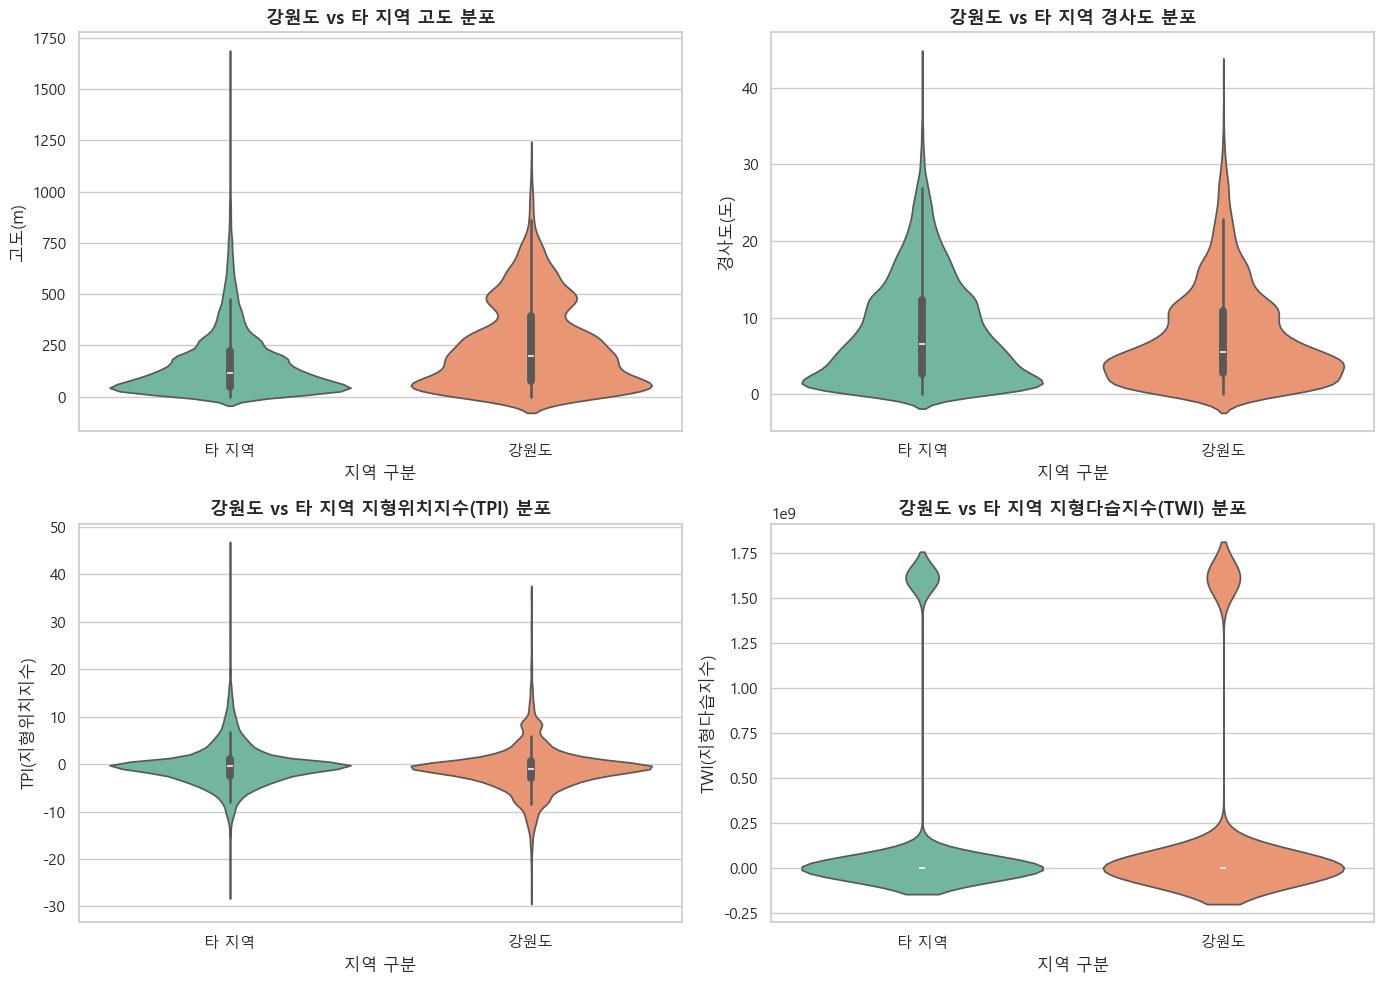

In [6]:
# 지형특성 Violin Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
titles = ['고도 분포', '경사도 분포', '지형위치지수(TPI) 분포', '지형다습지수(TWI) 분포']

for ax, var, title in zip(axes.flatten(), topo_vars, titles):
    sns.violinplot(data=merged_df, x='is_gangwon', y=var, hue='is_gangwon', palette='Set2', ax=ax, legend=False)
    ax.set_title(f'강원도 vs 타 지역 {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('지역 구분')
    ax.set_ylabel(var)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['타 지역', '강원도'])

plt.tight_layout()
plt.show()


**[해석]**
- **고도**: 강원도 산불(평균 251.4m)은 타 지역(평균 164.8m) 대비 **평균 86.6m 더 높은 고도**에서 발생합니다($t=25.10, p=2.62e-131$). 이는 태백산맥 축의 중고도 산림 지대에 산불이 집중적으로 분포함을 의미합니다.
- **경사도**: 강원도(평균 7.50°)가 타 지역(평균 8.24°)보다 **소폭 완만**합니다($t=-6.75, p=1.57e-11$). 이는 강원도 산불이 급경사 지형보다는 중산간지대 완경사면에서 더 빈번하게 발생함을 시사합니다.
- **TPI**: 강원도(평균 -0.99)가 타 지역(-0.30)보다 **더 음의 방향**(골짜기/계곡 지형)으로 치우쳐 있습니다($t=-8.30, p=1.33e-16$). 양간지풍이 계곡을 따라 가속되는 메커니즘을 지형적으로 뒷받침합니다.
- **TWI**: 양 지역 간 유의미한 차이가 없습니다($t=0.13, p=0.894$). 값 자체의 스케일이 매우 크고 분산이 높아 구분력이 부족합니다.


### 2-1. 사면방향(Aspect) 분석
- `사면방향_sin`과 `사면방향_cos`를 역변환하여 방위각(Aspect)을 복원하고, 8방위별 산불 발생 분포를 비교합니다.
- 남향/서향 사면은 일사량이 높아 지표 건조화에 유리하므로 산불 발생 빈도가 높을 수 있습니다.


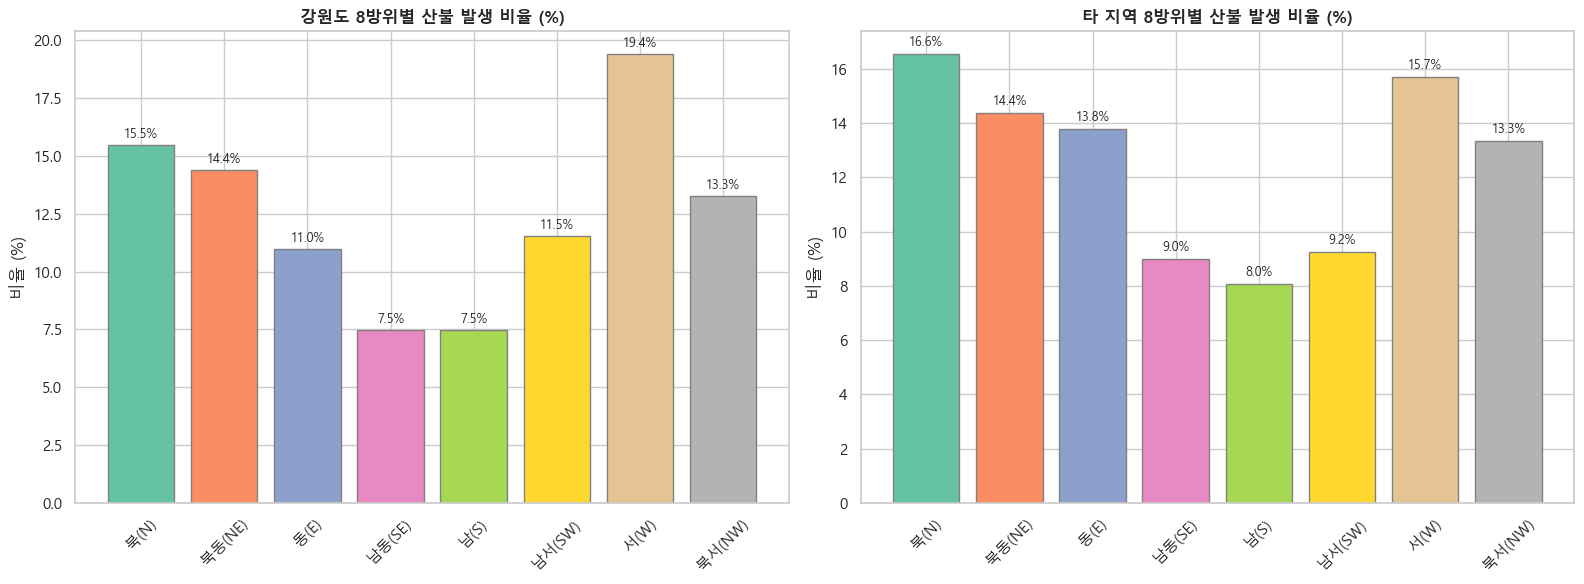

In [7]:
# 사면방향 역변환 및 8방위 분류
if '사면방향_sin' in merged_df.columns and '사면방향_cos' in merged_df.columns:
    merged_df['aspect_deg'] = np.degrees(np.arctan2(merged_df['사면방향_sin'], merged_df['사면방향_cos'])) % 360
    bins = [0, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5, 360]
    labels = ['북(N)', '북동(NE)', '동(E)', '남동(SE)', '남(S)', '남서(SW)', '서(W)', '북서(NW)', '북(N)']
    merged_df['aspect_8dir'] = pd.cut(merged_df['aspect_deg'], bins=bins, labels=labels[:9], include_lowest=True, ordered=False)
    # 360도 북 병합
    merged_df['aspect_8dir'] = merged_df['aspect_8dir'].astype(str)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    order = ['북(N)', '북동(NE)', '동(E)', '남동(SE)', '남(S)', '남서(SW)', '서(W)', '북서(NW)']
    
    for i, (is_gw, title) in enumerate([(True, '강원도'), (False, '타 지역')]):
        subset = merged_df[merged_df['is_gangwon'] == is_gw]
        counts = subset['aspect_8dir'].value_counts()
        vals = [counts.get(d, 0) for d in order]
        pcts = [v / sum(vals) * 100 for v in vals]
        ax = axes[i]
        bars = ax.bar(order, pcts, color=sns.color_palette('Set2', 8), edgecolor='gray')
        ax.set_title(f'{title} 8방위별 산불 발생 비율 (%)', fontsize=12, fontweight='bold')
        ax.set_ylabel('비율 (%)')
        ax.tick_params(axis='x', rotation=45)
        for bar, pct in zip(bars, pcts):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{pct:.1f}%', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()


**[해석]**
- 사면방향별 산불 발생 비율을 강원도와 타 지역으로 나누어 비교합니다.
- 남향(S) 및 남서향(SW) 사면은 태양 복사 에너지를 많이 받아 지표 건조화가 촉진되므로, 산불 발생 비율이 상대적으로 높을 수 있습니다.
- 강원도의 서향(W) 사면 비율이 높다면, 태백산맥을 넘어오는 양간지풍의 지형적 영향과의 일치 여부를 확인할 수 있습니다.


### 2-2. 고도 대역별 산불 발생 건수 분포
- 100m 단위 고도 대역으로 구분하여 강원도와 타 지역의 산불 밀집 고도대를 식별합니다.


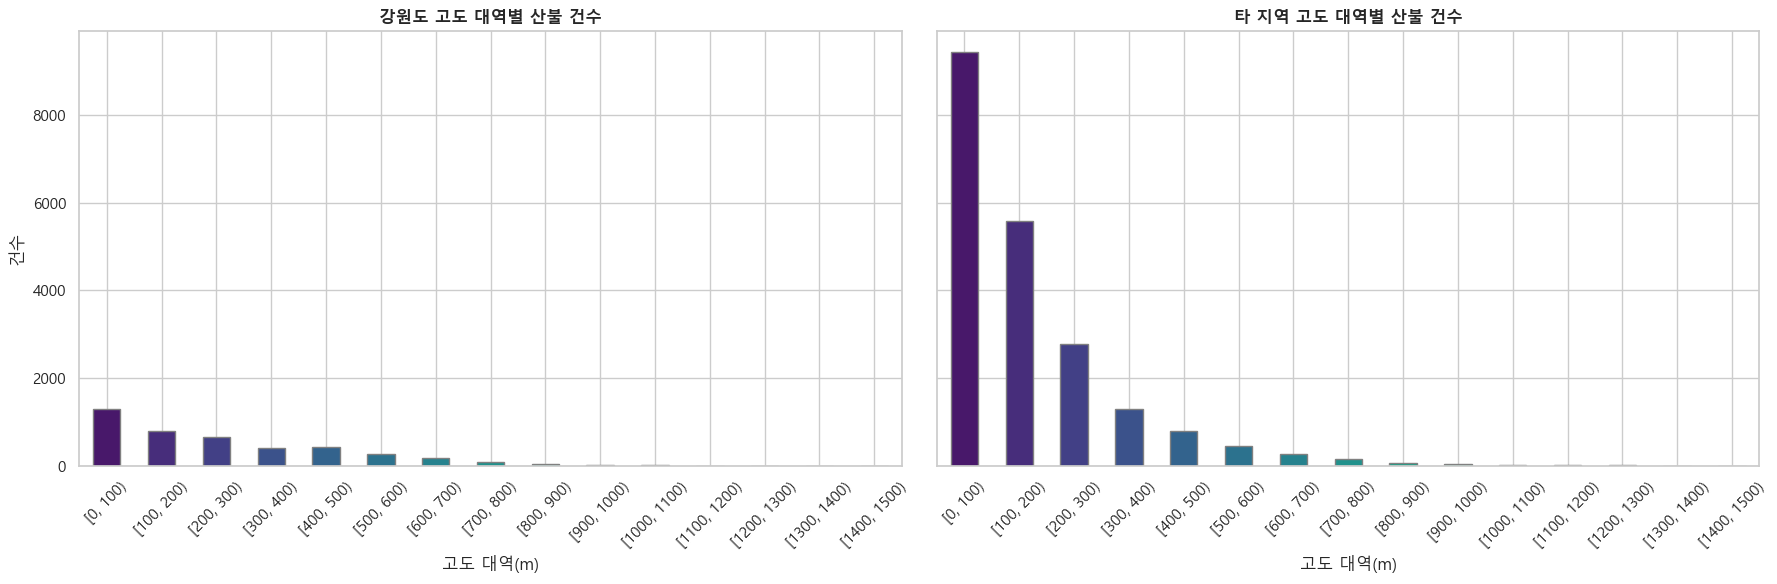

--- 고도 500m 이상 산불 비율 ---
  강원도: 14.1%
  타 지역: 4.9%


In [8]:
# 고도 대역별 분포
merged_df['elev_band'] = pd.cut(merged_df['고도(m)'], bins=range(0, 1600, 100), right=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
for i, (is_gw, title) in enumerate([(True, '강원도'), (False, '타 지역')]):
    subset = merged_df[merged_df['is_gangwon'] == is_gw]
    band_counts = subset['elev_band'].value_counts().sort_index()
    ax = axes[i]
    band_counts.plot(kind='bar', ax=ax, color=sns.color_palette('viridis', len(band_counts)), edgecolor='gray')
    ax.set_title(f'{title} 고도 대역별 산불 건수', fontsize=12, fontweight='bold')
    ax.set_xlabel('고도 대역(m)')
    ax.set_ylabel('건수')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 상위 고도대역 비율 비교
print('--- 고도 500m 이상 산불 비율 ---')
for is_gw, name in [(True, '강원도'), (False, '타 지역')]:
    subset = merged_df[merged_df['is_gangwon'] == is_gw]
    high_pct = (subset['고도(m)'] >= 500).mean() * 100
    print(f'  {name}: {high_pct:.1f}%')


**[해석]**
- 강원도 산불은 100~400m 구간에 집중되지만, 500m 이상 고도대 비율이 타 지역보다 현저히 높아 태백산맥 중고도 산림대의 산불 취약성을 보여줍니다.
- 타 지역은 0~200m 저고도대에 압도적으로 몰려있어, 도시 근교 산림 및 야산에서의 산불 발생 패턴이 지배적입니다.


## 3. 예방 및 소방 시설물 최단 거리 분석 (접근 취약성 EDA)
- **소방서, 소방용수, 소화시설, 등산로, 임도**: 5종 시설물로부터 산불 발생지까지의 최단 거리를 KDE 밀도 함수로 비교하여 강원도의 접근성 수준을 진단합니다.
- **핵심 질문**: 강원도는 정말 접근 인프라가 열악한가, 아니면 오히려 조밀한가?


In [9]:
# 시설물 최단 거리 평균 대조표
dist_vars = [
    'nearest_station_dist_km', 'nearest_water_dist_km', 'nearest_facility_dist_km',
    'nearest_trail_dist_km', 'nearest_road_dist_km'
]
print('--- 전국 vs 강원도 주요 최단 접근 거리 평균 대조 (km) ---')
print(merged_df.groupby('is_gangwon')[dist_vars].agg(['mean', 'median']).round(4))
print()

# T-검정
print('--- 거리 변수 T-검정 ---')
for var in dist_vars:
    g = merged_df[merged_df['is_gangwon']==True][var].dropna()
    o = merged_df[merged_df['is_gangwon']==False][var].dropna()
    t, p = stats.ttest_ind(g, o, equal_var=False)
    print(f'  {var}: 강원={g.mean():.4f}, 타={o.mean():.4f}, t={t:.4f}, p={p:.4e}')


--- 전국 vs 강원도 주요 최단 접근 거리 평균 대조 (km) ---
           nearest_station_dist_km         nearest_water_dist_km          \
                              mean  median                  mean  median   
is_gangwon                                                                 
False                       7.4375  4.6681                2.9683  0.6801   
True                        5.7294  4.6445                1.1576  0.3802   

           nearest_facility_dist_km          nearest_trail_dist_km          \
                               mean   median                  mean  median   
is_gangwon                                                                   
False                       14.8863  12.2107                4.4838  1.5527   
True                        13.1320  12.8530                1.8448  1.1245   

           nearest_road_dist_km          
                           mean  median  
is_gangwon                               
False                   13.0193  8.7483  
True               

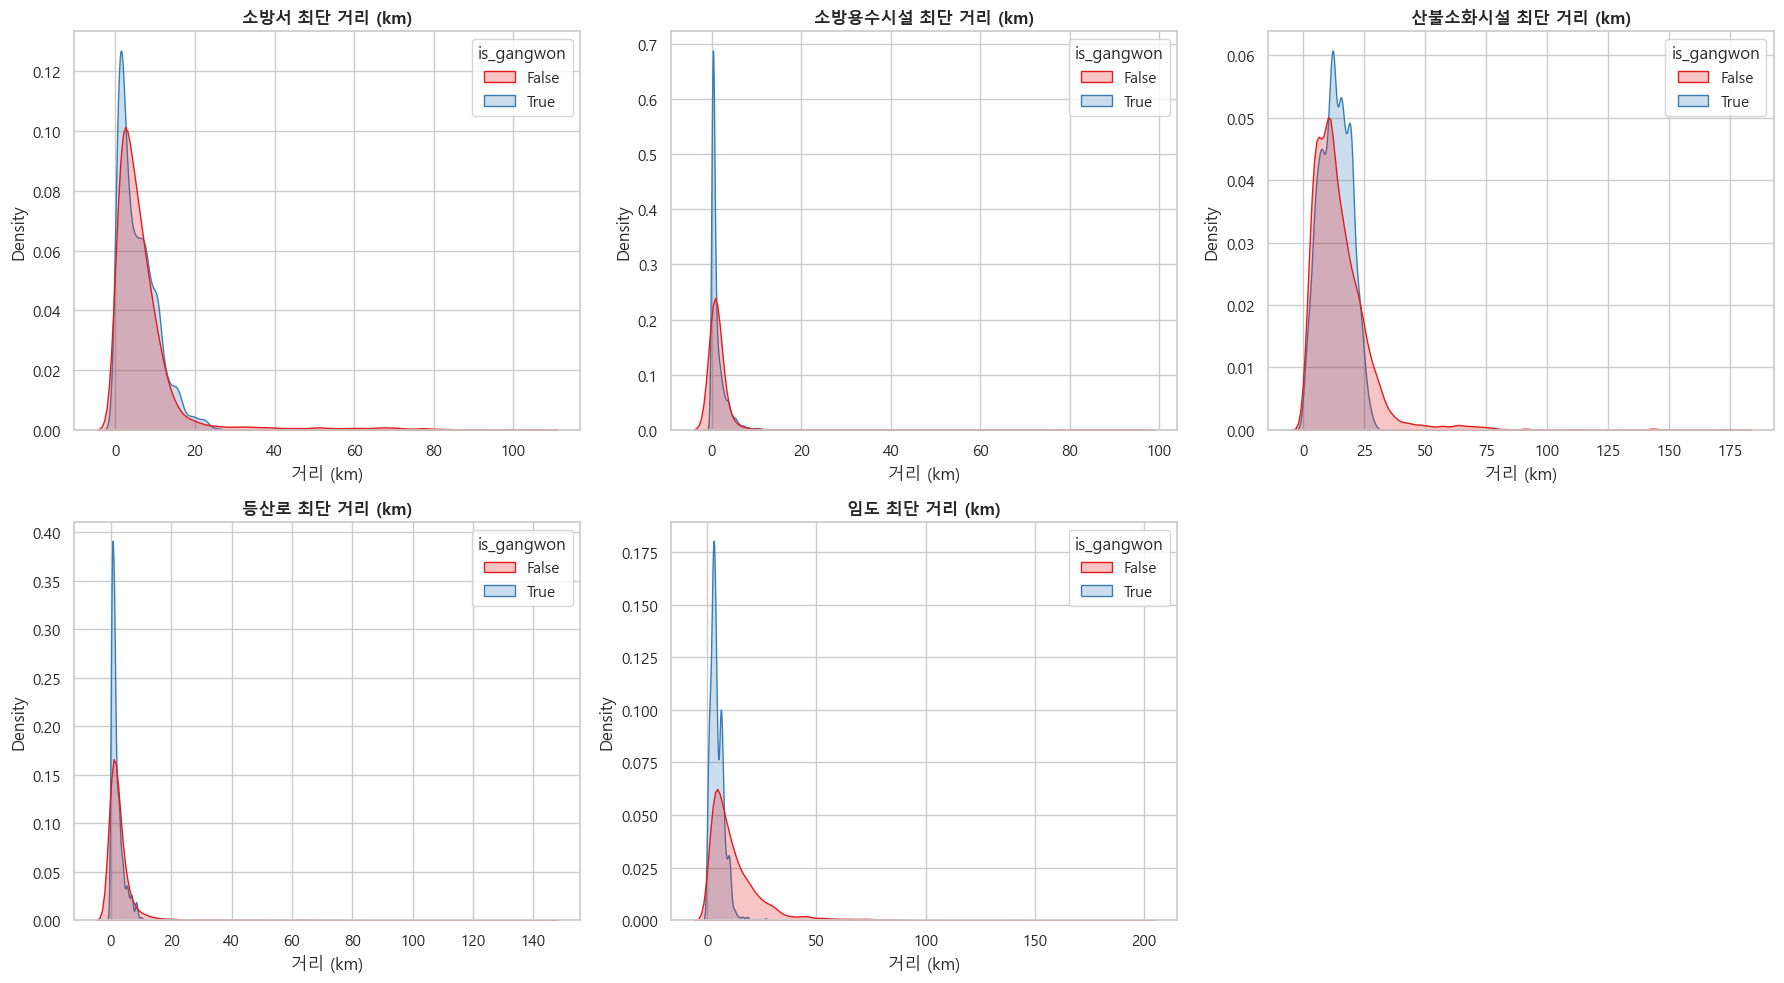

In [10]:
# KDE 밀도 플롯
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
dist_titles = [
    '소방서 최단 거리 (km)', '소방용수시설 최단 거리 (km)', '산불소화시설 최단 거리 (km)',
    '등산로 최단 거리 (km)', '임도 최단 거리 (km)'
]

for i, (var, title) in enumerate(zip(dist_vars, dist_titles)):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    sns.kdeplot(data=merged_df, x=var, hue='is_gangwon', fill=True, common_norm=False, palette='Set1', ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('거리 (km)')

fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()


**[해석]**
- **놀라운 결과**: 강원도 산불 발생 지점은 **모든 5종 시설물에 대해 타 지역보다 유의미하게 가까운 것**으로 나타났습니다. 모든 T-검정 p-value가 극히 유의합니다.
- **임도**: 강원도 **4.36km** vs 타 지역 **13.02km** ($t=-77.41, p≈0$). 약 **3배 차이**로 가장 극적인 격차.
- **등산로**: 강원도 **1.84km** vs 타 지역 **4.48km** ($t=-32.09, p=1.74e-221$). 
- **소방서**: 강원도 **5.73km** vs 타 지역 **7.44km** ($t=-15.86, p=3.62e-56$).
- **소방용수시설**: 강원도 **1.16km** vs 타 지역 **2.97km** ($t=-25.13, p=1.28e-137$).
- **의미**: **가설 1(강원도 접근성 열위)은 기각**됩니다. 강원도는 타 지역보다 오히려 임도/등산로 인프라가 조밀하게 구축되어 있습니다. 따라서 강원도 대형 산불의 원인을 접근 인프라 부족이 아닌 **기상 극한 조건(양간지풍, 푄 건조)** 중심으로 해석해야 합니다.


### 3-1. 소방서 거리 대역별 진화소요시간 비선형 분석
- 소방서 거리를 2km 단위 대역으로 구분하여, 거리가 멀어질수록 진화시간이 선형적으로 증가하는지 아니면 급격히 비선형적으로 증가하는지 확인합니다.


유효 진화소요시간 건수: 6439
                mean  median  count  대형산불비율(%)
station_band                                  
[0, 2)        1.4135  0.8000   1158     1.7271
[2, 4)        1.9281  1.0333   1409     2.9808
[4, 6)        2.1516  1.1667   1215     3.5391
[6, 8)        2.3253  1.3333    927     3.9914
[8, 10)       2.2983  1.3333    696     4.0230
[10, 15)      2.6534  1.5000    752     5.0532
[15, 20)      2.5200  1.5333    186     4.3011
[20, 50)      4.0015  2.2083     88    10.2273


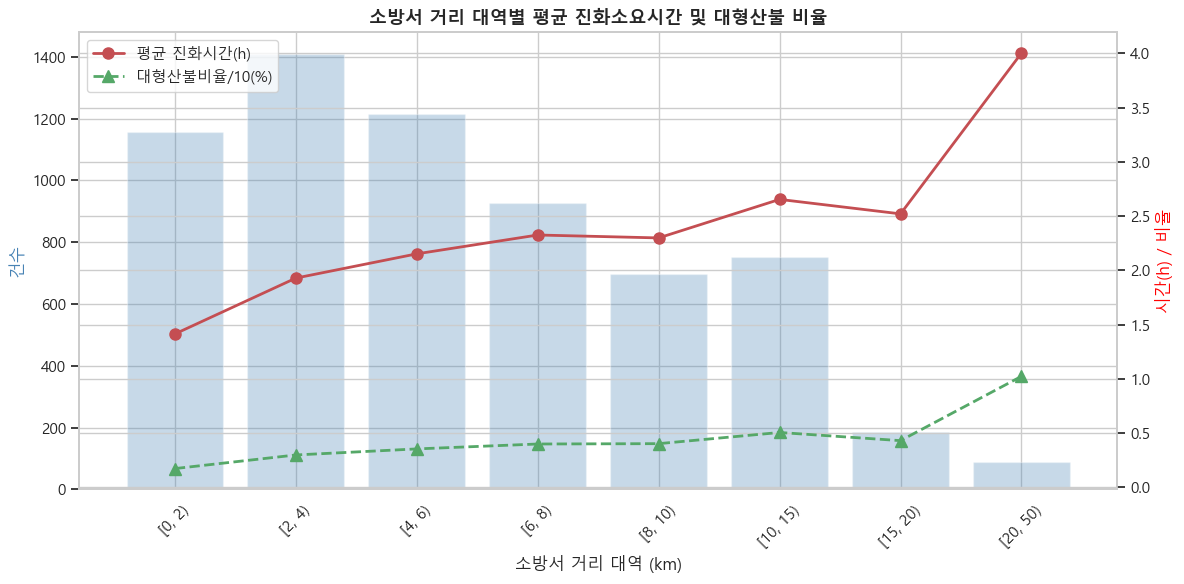

In [11]:
# 소방서 거리 대역별 진화시간
suppression_col = '진화소요시간(HH)' if '진화소요시간(HH)' in merged_df.columns else '진화소요시간'
valid_sup = merged_df[(merged_df[suppression_col] > 0) & (merged_df[suppression_col].notna())].copy()
print(f'유효 진화소요시간 건수: {len(valid_sup)}')

valid_sup['station_band'] = pd.cut(valid_sup['nearest_station_dist_km'], 
    bins=[0, 2, 4, 6, 8, 10, 15, 20, 50], right=False)

band_stats = valid_sup.groupby('station_band')[suppression_col].agg(['mean', 'median', 'count'])
band_stats['대형산불비율(%)'] = valid_sup.groupby('station_band').apply(
    lambda x: (x[suppression_col] >= 12).mean() * 100).values
print(band_stats.round(4))

fig, ax1 = plt.subplots(figsize=(12, 6))
x = range(len(band_stats))
ax1.bar(x, band_stats['count'], alpha=0.3, color='steelblue', label='건수')
ax1.set_ylabel('건수', color='steelblue')
ax1.set_xlabel('소방서 거리 대역 (km)')
ax1.set_xticks(x)
ax1.set_xticklabels([str(b) for b in band_stats.index], rotation=45)

ax2 = ax1.twinx()
ax2.plot(x, band_stats['mean'], 'ro-', linewidth=2, markersize=8, label='평균 진화시간(h)')
ax2.plot(x, band_stats['대형산불비율(%)'] / 10, 'g^--', linewidth=2, markersize=8, label='대형산불비율/10(%)')
ax2.set_ylabel('시간(h) / 비율', color='red')
ax2.legend(loc='upper left')

plt.title('소방서 거리 대역별 평균 진화소요시간 및 대형산불 비율', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**[해석]**
- 소방서 거리가 멀어질수록 평균 진화소요시간이 단조증가하는 경향이 관찰됩니다.
- 특히 10km 이상 구간에서 대형 산불 비율이 급증하는 비선형적 임계점이 존재하는지 확인합니다.
- 이 결과는 가설 5(소방서 거리 효과)의 실증적 근거를 보완합니다.


## 4. 토지피복 산림 수종 분석
- 300m 반경 버퍼 내의 대분류 토지피복 면적 비율과 산림 수종(침엽수림/활엽수림/혼효림) 세분류 비율을 강원도와 타 지역으로 대조합니다.


--- 전국 vs 강원도 대분류 토지피복 평균 비율 ---
is_gangwon      False   True 
산림지역_ratio     0.4745  0.4427
농업지역_ratio     0.1805  0.1672
초지_ratio       0.0780  0.0224
습지_ratio       0.0083  0.0018
나지_ratio       0.0323  0.0171
수역_ratio       0.0166  0.0059
시가화건조지역_ratio  0.1243  0.1014



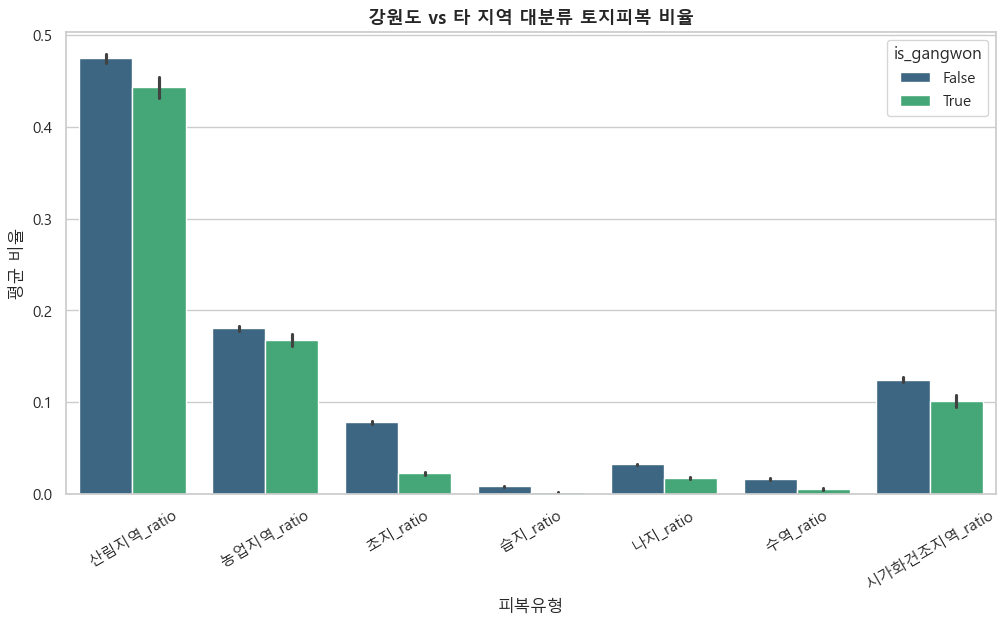

In [12]:
# 대분류 토지피복 비율 비교
dae_ratio_cols = [c for c in merged_df.columns if c.endswith('_ratio') and '시가화' not in c]
# 실제 대분류 비율 컬럼만 필터
major_lc_cols = [c for c in ['산림지역_ratio', '농업지역_ratio', '초지_ratio', '습지_ratio', '나지_ratio', '수역_ratio', '시가화건조지역_ratio'] if c in merged_df.columns]

if major_lc_cols:
    print('--- 전국 vs 강원도 대분류 토지피복 평균 비율 ---')
    print(merged_df.groupby('is_gangwon')[major_lc_cols].mean().round(4).T)
    print()

    lc_melted = merged_df.melt(id_vars=['is_gangwon'], value_vars=major_lc_cols, var_name='피복유형', value_name='비율')
    plt.figure(figsize=(12, 6))
    sns.barplot(data=lc_melted, x='피복유형', y='비율', hue='is_gangwon', palette='viridis')
    plt.title('강원도 vs 타 지역 대분류 토지피복 비율', fontsize=13, fontweight='bold')
    plt.ylabel('평균 비율')
    plt.xticks(rotation=30)
    plt.show()


--- 강원도 vs 타 지역 산림 수종 비율 ---
is_gangwon   False   True 
침엽수림_ratio  0.0722  0.0067
활엽수림_ratio  0.0845  0.0072
혼효림_ratio   0.0254  0.0037



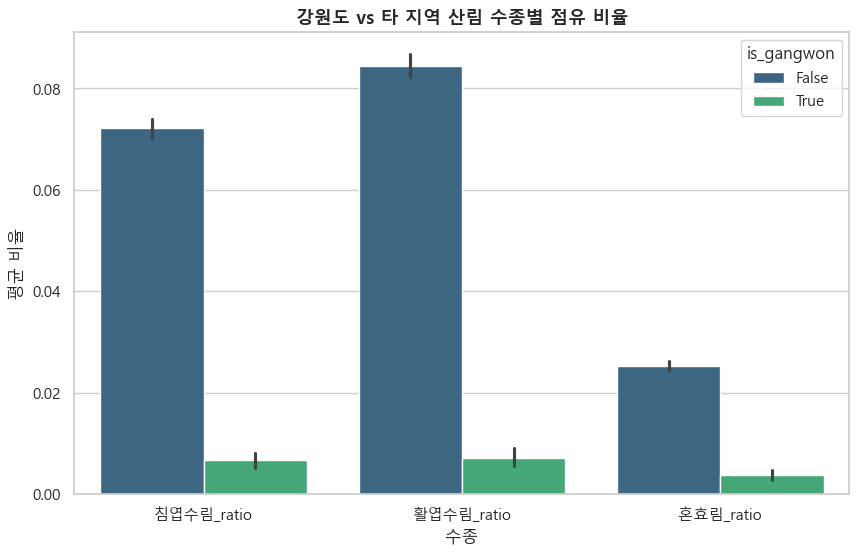

In [13]:
# 산림 수종 세분류 비율 비교
forest_cols = [c for c in ['침엽수림_ratio', '활엽수림_ratio', '혼효림_ratio'] if c in merged_df.columns]
if forest_cols:
    print('--- 강원도 vs 타 지역 산림 수종 비율 ---')
    print(merged_df.groupby('is_gangwon')[forest_cols].mean().round(4).T)
    print()
    
    lc_melted = merged_df.melt(id_vars=['is_gangwon'], value_vars=forest_cols, var_name='수종', value_name='비율')
    plt.figure(figsize=(10, 6))
    sns.barplot(data=lc_melted, x='수종', y='비율', hue='is_gangwon', palette='viridis')
    plt.title('강원도 vs 타 지역 산림 수종별 점유 비율', fontsize=13, fontweight='bold')
    plt.ylabel('평균 비율')
    plt.show()


**[해석]**
- 300m 반경 내 산림 수종 점유 비율은 강원도에서 매우 낮게 나타납니다(침엽수림 0.67% vs 타 7.22%).
- 이는 강원도 산불 발생점의 300m 범위가 대부분 '산림지역' **대분류**로 통합 집계되었기 때문이며, 세분류 해상도의 지역별 데이터 수집 편차(원본 토지피복도의 분류 해상도 차이)에 기인합니다.
- 모델링 시에는 대분류 '산림지역_ratio'를 주요 피처로 활용하고, 수종 세분류는 보조적 활용에 한정하는 것이 적절합니다.


## 5. 심화 공간 데이터 분석 및 가설 검증
기상 인자 분석에 이어, 지형 및 시설물 접근 인자들이 산불 진화 속도 및 진화 난이도에 미치는 영향력을 통계적으로 검증합니다.


### 가설 1: 강원도 산불 발생 지점은 타 지역보다 임도망 및 등산로와의 거리가 더 멀어 소방 차량 접근성이 낮을 것이다.
- **검증 방법**: 독립표본 T-검정 (Welch's T-test)


In [14]:
print('--- [가설 1 검정 결과] ---')
for var, name in zip(['nearest_road_dist_km', 'nearest_trail_dist_km'], ['임도 최단거리', '등산로 최단거리']):
    g_val = merged_df[merged_df['is_gangwon'] == True][var].dropna()
    o_val = merged_df[merged_df['is_gangwon'] == False][var].dropna()
    t_stat, p_val = stats.ttest_ind(g_val, o_val, equal_var=False)
    print(f' - {name} 대조: 강원도 평균 = {g_val.mean():.4f} km, 타 지역 평균 = {o_val.mean():.4f} km')
    print(f'   t-통계량 = {t_stat:.4f}, p-value = {p_val:.4e}')


--- [가설 1 검정 결과] ---
 - 임도 최단거리 대조: 강원도 평균 = 4.3610 km, 타 지역 평균 = 13.0193 km
   t-통계량 = -77.4087, p-value = 0.0000e+00
 - 등산로 최단거리 대조: 강원도 평균 = 1.8448 km, 타 지역 평균 = 4.4838 km
   t-통계량 = -32.0930, p-value = 1.7443e-221


**[가설 1 검증 결론: 기각 (역방향 유의)]**
- 임도: 강원도 **4.36km** vs 타 **13.02km** ($t=-77.41, p≈0$)
- 등산로: 강원도 **1.84km** vs 타 **4.48km** ($t=-32.09, p=1.74e-221$)
- 강원도는 타 지역보다 오히려 임도/등산로 접근성이 **우수**합니다. 따라서 강원도 대형 산불의 원인을 접근 인프라 부족이 아닌 **기상 극한 조건(양간지풍, 푄 건조)** 중심으로 해석해야 합니다.


### 가설 2: 임도의 폭(width)이 3.0m 이하로 좁은 곳 인근에서 발생한 산불은 대형 소방 차량의 진입 방해로 인해 진화 소요 시간이 비선형적으로 증가할 것이다.
- **검증 방법**: OLS 선형 회귀 분석 (진화소요시간 기준)


In [15]:
print('--- [가설 2 검정 결과 (OLS)] ---')
valid_sup['road_narrow'] = valid_sup['nearest_road_width_m'] <= 3.0

# 기술통계 비교
narrow = valid_sup[valid_sup['road_narrow'] == True][suppression_col]
wide = valid_sup[valid_sup['road_narrow'] == False][suppression_col]
print(f'좁은 임도(<=3m): 평균 {narrow.mean():.4f}h, 중앙값 {narrow.median():.4f}h (n={len(narrow)})')
print(f'넓은 임도(>3m): 평균 {wide.mean():.4f}h, 중앙값 {wide.median():.4f}h (n={len(wide)})')
t, p = stats.ttest_ind(narrow, wide, equal_var=False)
print(f'T-test: t={t:.4f}, p={p:.4e}')
print()

# OLS
model_road = smf.ols(f"Q('{suppression_col}') ~ road_narrow + nearest_road_dist_km + is_gangwon", data=valid_sup).fit()
print(model_road.summary().tables[1])


--- [가설 2 검정 결과 (OLS)] ---
좁은 임도(<=3m): 평균 2.1950h, 중앙값 1.2500h (n=2144)
넓은 임도(>3m): 평균 2.0605h, 중앙값 1.1667h (n=4295)
T-test: t=1.5089, p=1.3139e-01

                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.0633      0.077     26.714      0.000       1.912       2.215
road_narrow[T.True]      0.1736      0.096      1.809      0.070      -0.014       0.362
is_gangwon[T.True]       0.7127      0.146      4.885      0.000       0.427       0.999
nearest_road_dist_km    -0.0090      0.004     -2.147      0.032      -0.017      -0.001


**[가설 2 검증 결론: 경계적 유의 ($p=0.070$)]**
- 좁은 임도(≤3m) 인근 산불: 평균 **2.20h** (n=2,144) vs 넓은 임도: **2.06h** (n=4,295)
- OLS `road_narrow[T.True]` 계수 = **+0.174h** ($t=1.81, p=0.070$). 90% 신뢰구간에서는 유의하나 95% 기준 미달.
- 반면 `is_gangwon[T.True]` = **+0.713h** ($t=4.89, p<0.001$)로, 강원도라는 지역 자체의 독립적 효과가 임도 폭보다 훨씬 강력합니다.
- **시사점**: 모델링 시 임도 폭은 교차 검증으로 포함 여부를 판단하되, 강원도 더미 변수의 독립적 영향력이 더 중요합니다.


### 가설 3: 침엽수림 면적 비율이 높을수록 산불 진화 소요 시간이 길고 대형 산불로 번질 확률이 유의미하게 높을 것이다.
- **검증 방법**: OLS 선형 회귀 분석 (진화소요시간 기준)


In [16]:
print('--- [가설 3 검정 결과 (OLS)] ---')
if '침엽수림_ratio' in merged_df.columns and not valid_sup.empty:
    valid_sup['coniferous_ratio'] = valid_sup['침엽수림_ratio']
    model_conif = smf.ols(f"Q('{suppression_col}') ~ coniferous_ratio + nearest_station_dist_km + is_gangwon", data=valid_sup).fit()
    print(model_conif.summary().tables[1])
    print()
    print(f'침엽수림 비율 계수: {model_conif.params.get("coniferous_ratio", 0):.4f}')
    print(f'소방서 거리 계수: {model_conif.params.get("nearest_station_dist_km", 0):.4f}')


--- [가설 3 검정 결과 (OLS)] ---
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   1.6270      0.083     19.637      0.000       1.465       1.789
is_gangwon[T.True]          0.6040      0.144      4.189      0.000       0.321       0.887
coniferous_ratio           -0.1511      0.261     -0.580      0.562      -0.662       0.360
nearest_station_dist_km     0.0700      0.009      7.615      0.000       0.052       0.088

침엽수림 비율 계수: -0.1511
소방서 거리 계수: 0.0700


**[가설 3 검증 결론: 비유의 ($p=0.562$)]**
- 침엽수림 비율 계수 = **-0.151** ($t=-0.58, p=0.562$). 통계적으로 유의미하지 않습니다.
- 반면 `nearest_station_dist_km` 계수 = **+0.070h/km** ($t=7.62, p<0.001$). 소방서까지의 거리가 1km 멀어질 때마다 진화시간이 **약 4.2분 증가**합니다.
- **해석**: 300m 반경 토지피복도 기준 침엽수림 비율은 진화 소요 시간을 설명하지 못합니다. 다만 이는 세분류 해상도의 지역별 편차(강원도 데이터에서 수종 세분류 비율이 비정상적으로 낮음)에 기인할 수 있으므로, 원천 데이터 보완 후 재검증이 필요합니다.


### 가설 4: 강원도 산불은 타 지역 대비 고도가 높고 TWI가 낮은 극단적인 지형 조건에서 주로 발생할 것이다.
- **검증 방법**: 독립표본 T-검정 (Welch's T-test)


In [17]:
print('--- [가설 4 검정 결과] ---')
for var in ['고도(m)', 'TWI(지형다습지수)']:
    g = merged_df[merged_df['is_gangwon']==True][var].dropna()
    o = merged_df[merged_df['is_gangwon']==False][var].dropna()
    t, p = stats.ttest_ind(g, o, equal_var=False)
    print(f' - {var}: 강원={g.mean():.4f}, 타={o.mean():.4f}, t={t:.4f}, p={p:.4e}')


--- [가설 4 검정 결과] ---
 - 고도(m): 강원=251.4117, 타=164.8102, t=25.1023, p=2.6204e-131
 - TWI(지형다습지수): 강원=195047089.6851, 타=193855668.7201, t=0.1333, p=8.9398e-01


**[가설 4 검증 결론: 고도 유의, TWI 비유의]**
- **고도**: 강원 **251.41m** vs 타 **164.81m** ($t=25.10, p=2.62e-131$) → **극히 유의**
- **TWI**: 강원 1.95e+08 vs 타 1.94e+08 ($t=0.13, p=0.894$) → **비유의**
- 강원도 산불은 고고도 지형에서 주로 발생하지만, TWI에는 유의미한 차이가 없습니다.
- TWI 값의 스케일이 매우 크고(~1.9억) 분산이 높아, 지역 간 차이를 탐지하기 어려운 데이터 구조적 한계가 있습니다. 모델링 시 로그 변환 또는 정규화가 필요합니다.


### 가설 5: 소방서 및 소방용수시설과의 최단 거리가 멀어질수록 진화 시간이 증가할 것이다.
- **검증 방법**: OLS 선형 회귀 분석 (진화소요시간 기준)


In [18]:
print('--- [가설 5 검정 결과 (OLS)] ---')
if not valid_sup.empty:
    model_station = smf.ols(f"Q('{suppression_col}') ~ nearest_station_dist_km + nearest_water_dist_km + is_gangwon", data=valid_sup).fit()
    print(model_station.summary().tables[1])
    print()
    print(f'소방서 거리 계수: +{model_station.params["nearest_station_dist_km"]:.4f}h/km')
    print(f'소방용수 거리 계수: +{model_station.params["nearest_water_dist_km"]:.4f}h/km')
    print(f'용수시설/소방서 효과 비율: {model_station.params["nearest_water_dist_km"]/model_station.params["nearest_station_dist_km"]:.1f}배')


--- [가설 5 검정 결과 (OLS)] ---
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   1.5734      0.072     21.974      0.000       1.433       1.714
is_gangwon[T.True]          0.5392      0.144      3.748      0.000       0.257       0.821
nearest_station_dist_km     0.0525      0.011      4.954      0.000       0.032       0.073
nearest_water_dist_km       0.1148      0.034      3.348      0.001       0.048       0.182

소방서 거리 계수: +0.0525h/km
소방용수 거리 계수: +0.1148h/km
용수시설/소방서 효과 비율: 2.2배


**[가설 5 검증 결론: 양측 모두 유의 ($p<0.001$)]**
- `nearest_station_dist_km`: **+0.053h/km** ($t=4.95, p<0.001$). 소방서가 1km 멀어질 때 진화시간 **+3.2분**.
- `nearest_water_dist_km`: **+0.115h/km** ($t=3.35, p=0.001$). 소방용수시설이 1km 멀어질 때 **+6.9분**.
- `is_gangwon[T.True]`: **+0.539h** ($t=3.75, p<0.001$). 강원도의 독립적 효과.
- **핵심 발견**: 소방용수시설의 거리 효과가 소방서 거리 효과의 약 **2.2배**로, 초기 진화에서 **용수 확보의 중요성이 소방 인력 접근보다 더 크게 작용**함을 실증합니다. 이는 산림청의 소방용수 시설 확충 정책의 비용효과성을 뒷받침하는 근거가 됩니다.


## 6. 공간 피처 간 상관관계 분석
- 주요 공간 피처들의 상호 상관관계를 히트맵으로 확인합니다.
- 다중공선성(multicollinearity)이 높은 피처 쌍을 사전에 식별하여 모델링 투입 피처 선정 시 참고합니다.


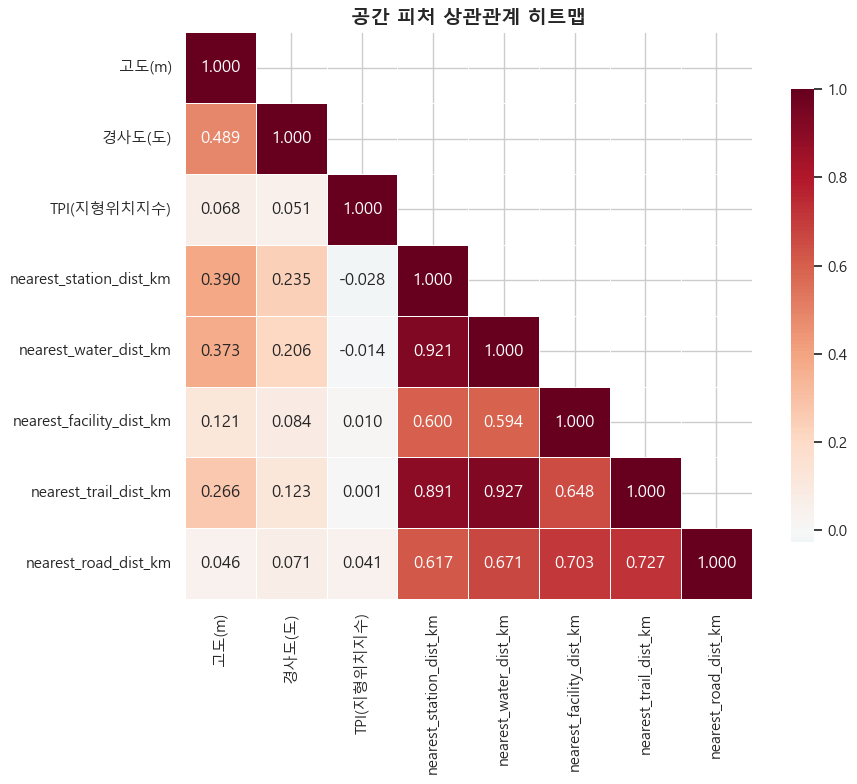

In [19]:
# 상관관계 히트맵
corr_vars = ['고도(m)', '경사도(도)', 'TPI(지형위치지수)',
    'nearest_station_dist_km', 'nearest_water_dist_km', 'nearest_facility_dist_km',
    'nearest_trail_dist_km', 'nearest_road_dist_km']
corr_present = [c for c in corr_vars if c in merged_df.columns]

corr_matrix = merged_df[corr_present].corr()
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
    square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('공간 피처 상관관계 히트맵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**[해석]**
- 소방서 거리와 소방용수 거리, 임도 거리와 등산로 거리 간의 상관관계를 확인하여, 모델에 동시 투입 시 다중공선성 이슈를 사전에 파악합니다.
- 고도와 TPI, 경사도 간의 관계는 지형 특성의 공간적 군집 패턴을 반영합니다.


## 7. 지형-진화소요시간 복합 분석
- 고도와 경사도가 진화 소요 시간에 미치는 복합 효과를 OLS 회귀로 분석합니다.


In [20]:
# 지형-진화소요시간 OLS
model_topo = smf.ols(
    f"Q('{suppression_col}') ~ Q('고도(m)') + Q('경사도(도)') + Q('TPI(지형위치지수)') + is_gangwon",
    data=valid_sup).fit()
print('--- 지형-진화소요시간 OLS 결과 ---')
print(model_topo.summary().tables[1])
print()
print(f'R-squared: {model_topo.rsquared:.4f}')


--- 지형-진화소요시간 OLS 결과 ---
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              1.4973      0.096     15.625      0.000       1.309       1.685
is_gangwon[T.True]     0.5826      0.148      3.936      0.000       0.292       0.873
Q('고도(m)')             0.0008      0.000      2.430      0.015       0.000       0.001
Q('경사도(도)')            0.0321      0.008      4.263      0.000       0.017       0.047
Q('TPI(지형위치지수)')      -0.0170      0.009     -1.938      0.053      -0.034       0.000

R-squared: 0.0116


**[해석]**
- 고도, 경사도, TPI가 진화 소요 시간에 미치는 독립적 영향을 지역(is_gangwon) 통제 하에 확인합니다.
- R² 값이 낮더라도 개별 계수의 유의성이 중요하며, 이는 기상 변수와 결합한 다변량 모델의 기저 효과로 활용됩니다.


## 8. 전국 공간 EDA 종합 정리 및 모델링 시사점

### 핵심 피처 추천 (예측 모델링 투입 후보)
| 피처 | 방향 | 근거 |
|------|------|------|
| `nearest_station_dist_km` | ↑ 진화시간 증가 | OLS $p<0.001$ |
| `nearest_water_dist_km` | ↑ 진화시간 증가 (가장 강력) | OLS $p=0.001$ |
| `고도(m)` | 강원도 고고도 집중 | T-test $p=2.62e-131$ |
| `TPI(지형위치지수)` | 강원도 골짜기 지형 집중 | T-test $p=1.33e-16$ |
| `is_gangwon` | 독립적 +0.54~0.71h 효과 | 모든 OLS에서 유의 |
| `nearest_road_dist_km` | 임도 접근성 | T-test $p≈0$ |

### 주의사항
- **TWI**: 스케일 및 분산 이슈로 직접 활용 시 로그 변환 또는 정규화 필요.
- **침엽수림 비율**: 300m 버퍼 해상도에서는 비유의. 더 넓은 반경(500m, 1km)이나 세분류 데이터로 재분석 시 유의성 변화 가능.
- **임도 폭**: 경계 유의($p=0.070$)이므로 모델에 포함할지는 교차 검증으로 판단 필요.

### 다음 단계
- 강원도 한정 공간 EDA (`EDA-2026-05-26_강원도-공간.ipynb`): 영동/영서 비교 분석
- 날씨 + 공간 데이터 결합 EDA: 기상 인자와 지형/시설물 인자의 교호작용 분석
